<a href="https://colab.research.google.com/github/kymo14/aura-nabila-projekUAS-MultimediaCerdas/blob/main/UAS_Multimedia_Cerdas_(YOLO26n).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nama  : Aura Nabila
# NIM   : 2305101089
# Kelas : 6D

## Ulangan Akhir Semester Multimedia Cerdas

In [1]:
!pip install ultralytics opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.4 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image as PILImage
from IPython.display import display, HTML, clear_output
import time
import os
import shutil
import random

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
source_dir = "/content/drive/MyDrive/uas_multimedia_cerdas/Fruit and Vegetable (Freash vs Rotten)/Unified_Dataset/banana"
print(os.listdir(source_dir))

['rotten', 'fresh']


In [5]:
random.seed(42)

output_dir = "/content/banana_dataset"
classes = ["fresh", "rotten"]
split_ratio = 0.8  # 80% train, 20% val

for cls in classes:
    files = os.listdir(os.path.join(source_dir, cls))
    random.shuffle(files)
    split_idx = int(len(files) * split_ratio)
    train_files = files[:split_idx]
    val_files = files[split_idx:]

    for subset, subset_files in [("train", train_files), ("val", val_files)]:
        dest = os.path.join(output_dir, subset, cls)
        os.makedirs(dest, exist_ok=True)
        for f in subset_files:
            shutil.copy(os.path.join(source_dir, cls, f), os.path.join(dest, f))

print("Selesai split dataset!")
print("Train fresh:", len(os.listdir(f"{output_dir}/train/fresh")))
print("Train rotten:", len(os.listdir(f"{output_dir}/train/rotten")))
print("Val fresh:", len(os.listdir(f"{output_dir}/val/fresh")))
print("Val rotten:", len(os.listdir(f"{output_dir}/val/rotten")))

Selesai split dataset!
Train fresh: 1600
Train rotten: 2240
Val fresh: 400
Val rotten: 560


In [6]:
model = YOLO("yolo11n-cls.pt")

results = model.train(
    data="/content/banana_dataset",
    epochs=10,
    imgsz=224
)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/banana_dataset, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

In [8]:
model = YOLO("runs/classify/train/weights/best.pt")
print(model.names)

{0: 'fresh', 1: 'rotten'}


In [9]:
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import Javascript

def take_photo(quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const video = document.createElement('video');
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(video);
      video.srcObject = stream;
      await video.play();
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      const ctx = canvas.getContext('2d');
      ctx.drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      video.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js("takePhoto({})".format(quality))
    return data

def js_to_image(js_reply):
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv2.imdecode(jpg_as_np, flags=1)
    return img

In [10]:
def start_streaming():
    THRESHOLD = 0.6  # ubah-ubah angka ini kalau hasil kurang pas

    while True:
        js = take_photo()
        img = js_to_image(js)

        results = model(img)[0]
        top_idx = results.probs.top1
        label = model.names[top_idx]
        conf = float(results.probs.top1conf)

        if conf < THRESHOLD:
            teks = f"Bukan pisang / tidak dikenali ({conf*100:.0f}%)"
            warna = (128, 128, 128)
        elif label == "fresh":
            teks = f"Ini pisang segar ({conf*100:.0f}%)"
            warna = (0, 255, 0)
        else:
            teks = f"Ini pisang busuk ({conf*100:.0f}%)"
            warna = (0, 0, 255)

        cv2.putText(img, teks, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, warna, 2)

        clear_output(wait=True)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        display(PILImage.fromarray(img_rgb))
        time.sleep(0.1)

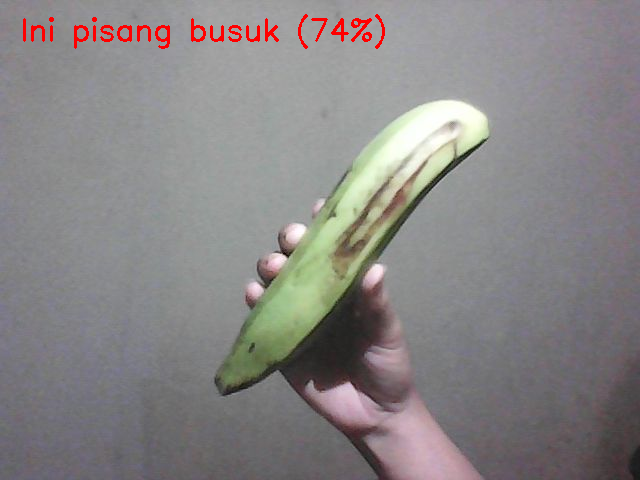

<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [17]:
start_streaming()